In [22]:
import numpy as np
import matplotlib.pyplot  as plt


In [23]:
reference_file = "RateAnalysis_data/reference_run_039512.npz"
equalized = "RateAnalysis_data/equalized_run_039511.npz"


In [34]:
data = np.load(equalized)

print(data.files)
print(data["target_frequency_khz"])

['run', 'channels', 'amplitude_bin_edges_adc', 'live_time_s', 'baseline_range', 'signal_range', 'tick_seconds', 'sample_type', 'target_source', 'target_frequency_khz', 'threshold_adc', 'frequency_before_khz', 'frequency_after_khz', 'histogram_before_counts', 'histogram_before_rate_hz', 'histogram_after_counts', 'histogram_after_rate_hz']
[3.95555121 4.88125959 5.04998245 4.72065193 4.06948077 3.51361171
 3.9309559  3.34892756 3.70013082 3.6439892 ]


In [30]:
def load_npz(file):
    with np.load(file, allow_pickle=False) as data:
        channels = data["channels"]
        bin_edges = data["amplitude_bin_edges_adc"]
        try:
            histogram_rate_hz = data["histogram_rate_hz"]
            frequencies_khz = data["frequency_khz"]
        except KeyError:
            histogram_rate_hz =  data["histogram_before_rate_hz"]
            frequencies_khz =  data["frequency_before_khz"]

    return channels, bin_edges,histogram_rate_hz, frequencies_khz


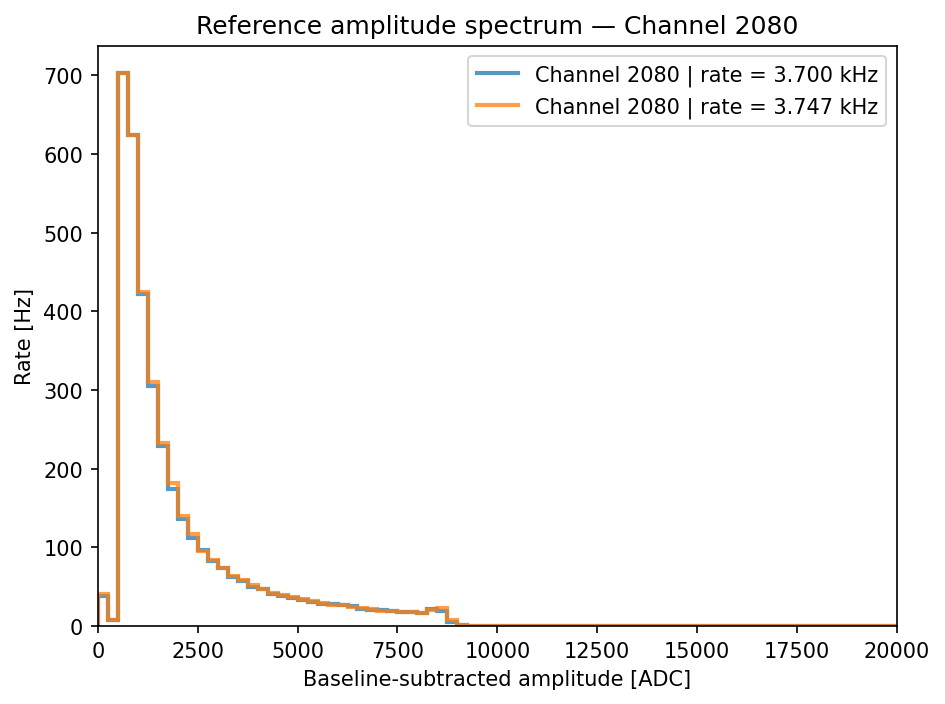

In [31]:

channel_to_plot = 2080

chs_ref, bin_ref, hist_ref, freq_ref = load_npz(reference_file)
chs_eq, bin_eq, hist_eq, freq_eq = load_npz(equalized)


channel_matches = np.where(chs_ref == channel_to_plot)[0]
if channel_matches.size == 0:
    raise ValueError(f"Channel {channel_to_plot} is not in the NPZ file")

index = channel_matches[0]

plt.figure(dpi=150)
plt.stairs(
    hist_ref[index],
    bin_ref,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Channel {channel_to_plot} | "
        f"rate = {freq_ref[index]:.3f} kHz"
    ),
)

plt.stairs(
    hist_eq[index],
    bin_eq,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Channel {channel_to_plot} | "
        f"rate = {freq_eq[index]:.3f} kHz"
    ),
)


plt.title(f"Reference amplitude spectrum — Channel {channel_to_plot}")
plt.xlabel("Baseline-to-peak amplitude, samples 50:1023 [ADC]")
plt.ylabel("Rate [Hz]")
plt.xlim(bin_ref[0], bin_ref[-1])
plt.legend()
plt.tight_layout()
plt.savefig(
    f"reference_histogram_channel_{channel_to_plot}.png",
    bbox_inches="tight",
)
plt.show()
